# Symptom scores and criterion fluctuations in superparticipants

Had help from AI. Asked it to base this script on a previous self-made script.

Exploratory analysis of the three separate symptom-based fits. Each point is one superparticipant.

The primary outcome is **log(SD of the posterior mean criterion trajectory)**, matching the trajectory summary used in the earlier notebook.


In [8]:
# List available result files for each symptom dimension.
for scale in run_ids:
    folder = base_dir / f"pooling_{scale}_n10" / "hmfc_results"
    print(f"\n{scale}:")
    files = sorted(folder.glob("*/*.dil"))
    for file in files:
        print(file, f"({file.stat().st_size / 1e6:.1f} MB)")
    if not files:
        print("No .dil files found.")


AnxiousDepression:
/data/leuven/382/vsc38292/super_participants/pooling_AnxiousDepression_n10/hmfc_results/62227425/hmfc_AnxiousDepression.dil (5254.1 MB)

Compulsivity:
/data/leuven/382/vsc38292/super_participants/pooling_Compulsivity_n10/hmfc_results/62228136/hmfc_Compulsivity.dil (5254.1 MB)

SocialWithdrawal:
/data/leuven/382/vsc38292/super_participants/pooling_SocialWithdrawal_n10/hmfc_results/62227427/hmfc_SocialWithdrawal.dil (5197.7 MB)


In [9]:
from pathlib import Path
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# Change this to your local super_participants folder if analyzing downloads.
base_dir = Path("/data/leuven/382/vsc38292/super_participants")
run_ids = {
    "AnxiousDepression": "62227425",
    "Compulsivity": "62228136",
    "SocialWithdrawal": "62227427",
}
burn_in = 500  # Same choice as the earlier 2,000-iteration analysis.
output_dir = base_dir / "analysis_results" / ("runs_" + "_".join(run_ids.values()))
output_dir.mkdir(parents=True, exist_ok=True)


## Load and summarize each fit
Only small summaries are retained between files. Loading the saved states still requires several GB of RAM. Use your own trusted `.dil` files. Scores are taken from the saved fit and joined explicitly by superparticipant ID.

In [10]:
def summarize_fit(path, expected_scale):

    saved = {}

    with path.open("rb") as handle:
        names = dill.load(handle)

        for name in names:
            value = dill.load(handle)

            if name == "posterior_samples_states":
                if value.ndim != 4 or not 0 <= burn_in < value.shape[1]:
                    raise ValueError("Check state dimensions and burn_in.")

                saved["trajectory"] = np.stack([
                    np.asarray(value[:, burn_in:, i, :]).mean(axis=(0, 1))
                    for i in range(value.shape[2])
                ])

            elif name == "posterior_samples_a":
                if value.ndim != 3:
                    raise ValueError("Unexpected shape for posterior_samples_a.")

                saved["a_mean"] = (
                    np.asarray(value[:, burn_in:, :])
                    .mean(axis=(0, 1))
                )

            elif name == "posterior_samples_sigmasq":
                if value.ndim != 3:
                    raise ValueError("Unexpected shape for posterior_samples_sigmasq.")

                saved["sigmasq_mean"] = (
                    np.asarray(value[:, burn_in:, :])
                    .mean(axis=(0, 1))
                )

            elif name in ("subj_ids", "scale", "group_scores", "masks"):
                saved[name] = value

            del value

    if saved["scale"] != expected_scale:
        raise ValueError(f"Wrong scale in {path}")

    ids = np.asarray(saved["subj_ids"])
    trajectory = saved["trajectory"]
    masks = np.asarray(saved["masks"], dtype=bool)

    assert trajectory.shape == masks.shape
    assert len(ids) == trajectory.shape[0]
    assert len(ids) == len(saved["a_mean"])
    assert len(ids) == len(saved["sigmasq_mean"])

    sd = np.array([
        row[mask].std(ddof=1)
        for row, mask in zip(trajectory, masks)
    ])

    mad = np.array([
        np.mean(np.abs(row[mask] - row[mask].mean()))
        for row, mask in zip(trajectory, masks)
    ])

    result = pd.DataFrame({
        "superparticipant": ids,
        "sd_criterion": sd,
        "mad_criterion": mad,
        "a_mean": saved["a_mean"],
        "sigmasq_mean": saved["sigmasq_mean"],
    })

    result = result.merge(
        saved["group_scores"],
        on="superparticipant",
        how="left",
        validate="one_to_one",
        indicator=True
    )

    assert result["_merge"].eq("both").all()
    result = result.drop(columns="_merge")

    # Check finite values
    assert np.isfinite(
        result[
            [
                "symptom_mean",
                "sd_criterion",
                "a_mean",
                "sigmasq_mean"
            ]
        ]
    ).all().all()

    # Check positivity before log-transforming
    assert (result["sd_criterion"] > 0).all(), \
        "Cannot log non-positive criterion SD"

    assert (result["sigmasq_mean"] > 0).all(), \
        "Cannot log non-positive sigma^2"

    # Log-transform outcomes
    result["log_sd_criterion"] = np.log(result["sd_criterion"])
    result["log_sigmasq"] = np.log(result["sigmasq_mean"])

    # Standardize symptom score
    score_sd = result["symptom_mean"].std(ddof=1)

    assert score_sd > 0

    result["symptom_z"] = (
        result["symptom_mean"] -
        result["symptom_mean"].mean()
    ) / score_sd

    return result

## Three separate regressions
Regressions for trajectory variability, a, and sigma^2

In [11]:

outcomes = {
    "log_sd_criterion": "log criterion SD",
    "a_mean": "autoregressive coefficient a",
    "log_sigmasq": "log sigma^2",
}

tables = {}
models = {}
rows = []

for scale, run_id in run_ids.items():

    path = (
        base_dir
        / f"pooling_{scale}_n10"
        / "hmfc_results"
        / run_id
        / f"hmfc_{scale}.dil"
    )

    if not path.is_file():
        raise FileNotFoundError(f"Result not available yet: {path}")

    df = summarize_fit(path, scale)
    tables[scale] = df

    X = sm.add_constant(df[["symptom_z"]], has_constant="add")

    for outcome, label in outcomes.items():

        fit = sm.OLS(df[outcome], X).fit(cov_type="HC3")

        low, high = fit.conf_int().loc["symptom_z"]

        rows.append({
            "scale": scale,
            "outcome": outcome,
            "n_groups": len(df),
            "beta": fit.params["symptom_z"],
            "ci_low": low,
            "ci_high": high,
            "p": fit.pvalues["symptom_z"],
            "r_squared": fit.rsquared
        })

        models[(scale, outcome)] = fit

    df.to_csv(
        output_dir / f"group_summary_{scale}.csv",
        index=False
    )

results = pd.DataFrame(rows)

# Holm correction separately within each outcome
results["p_holm"] = np.nan

for outcome in outcomes:
    mask = results["outcome"] == outcome
    results.loc[mask, "p_holm"] = multipletests(
        results.loc[mask, "p"],
        method="holm"
    )[1]

results.to_csv(
    output_dir / "regression_results_all_parameters.csv",
    index=False
)

print(results.round(4).to_string(index=False))

            scale          outcome  n_groups    beta  ci_low  ci_high      p  r_squared  p_holm
AnxiousDepression log_sd_criterion       110 -0.0002 -0.0491   0.0486 0.9920     0.0000  1.0000
AnxiousDepression           a_mean       110 -0.0003 -0.0015   0.0008 0.5946     0.0029  0.5946
AnxiousDepression      log_sigmasq       110  0.0109 -0.0393   0.0610 0.6707     0.0019  0.8083
     Compulsivity log_sd_criterion       110 -0.0830 -0.1278  -0.0383 0.0003     0.0846  0.0008
     Compulsivity           a_mean       110 -0.0022 -0.0031  -0.0013 0.0000     0.1305  0.0000
     Compulsivity      log_sigmasq       110 -0.0239 -0.0800   0.0322 0.4041     0.0070  0.8083
 SocialWithdrawal log_sd_criterion       110 -0.0004 -0.0499   0.0490 0.9864     0.0000  1.0000
 SocialWithdrawal           a_mean       110 -0.0006 -0.0017   0.0004 0.2454     0.0135  0.4907
 SocialWithdrawal      log_sigmasq       110  0.0351 -0.0167   0.0869 0.1837     0.0176  0.5511



# Check distributions before and after log transformation



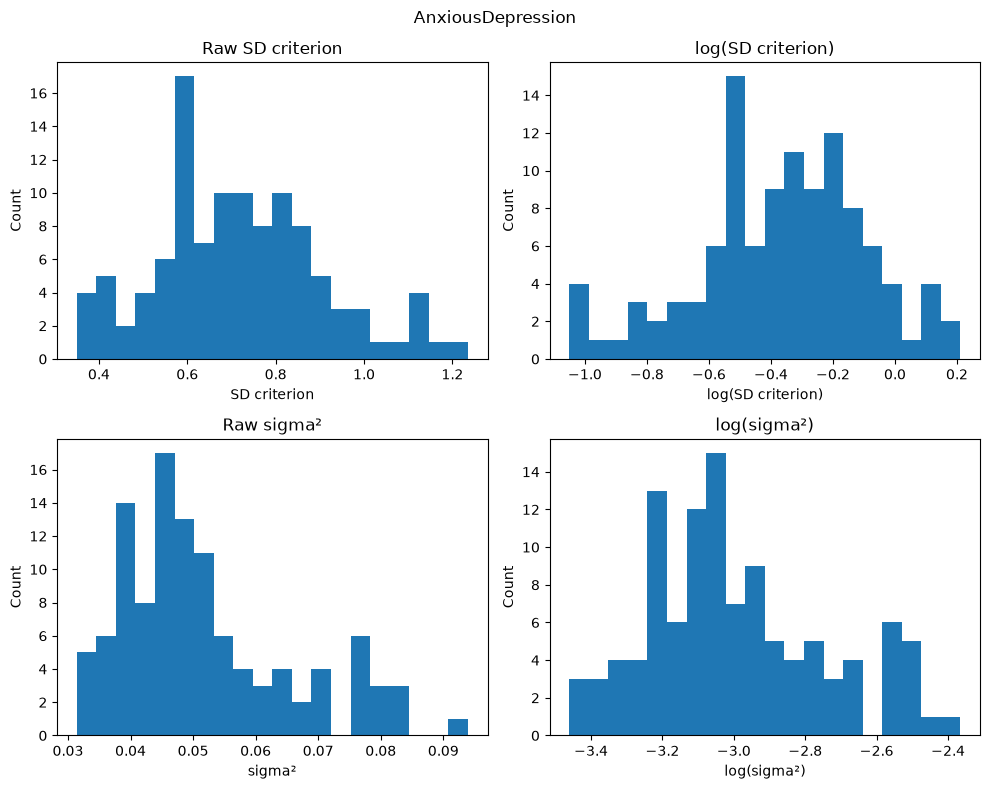

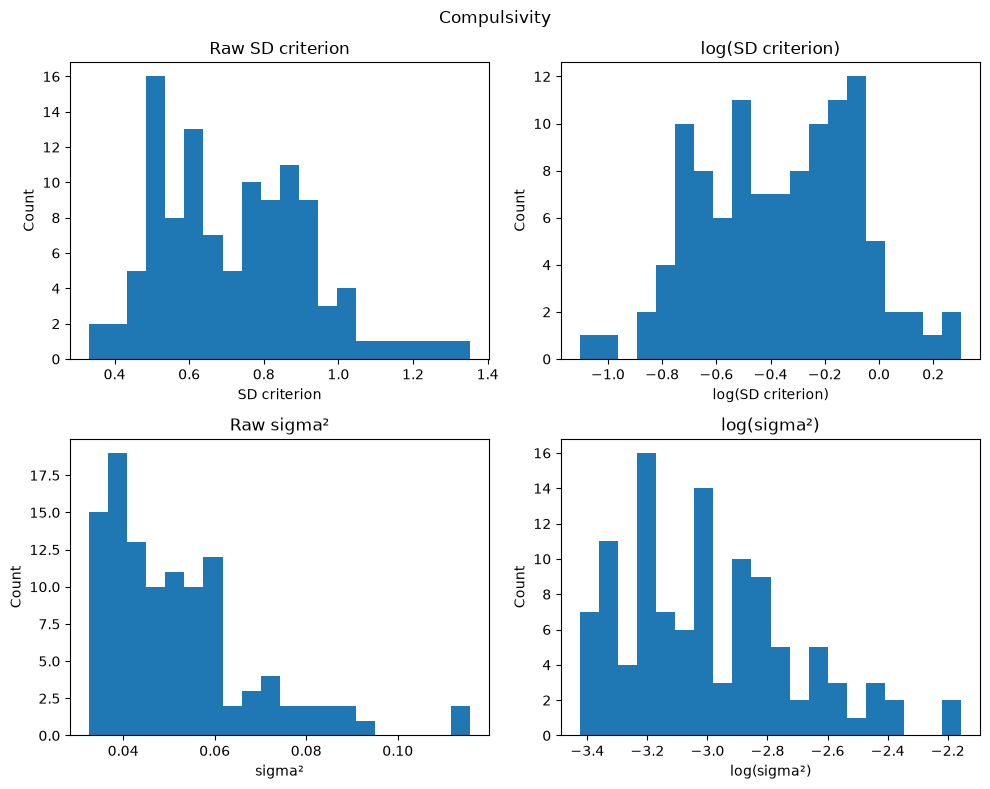

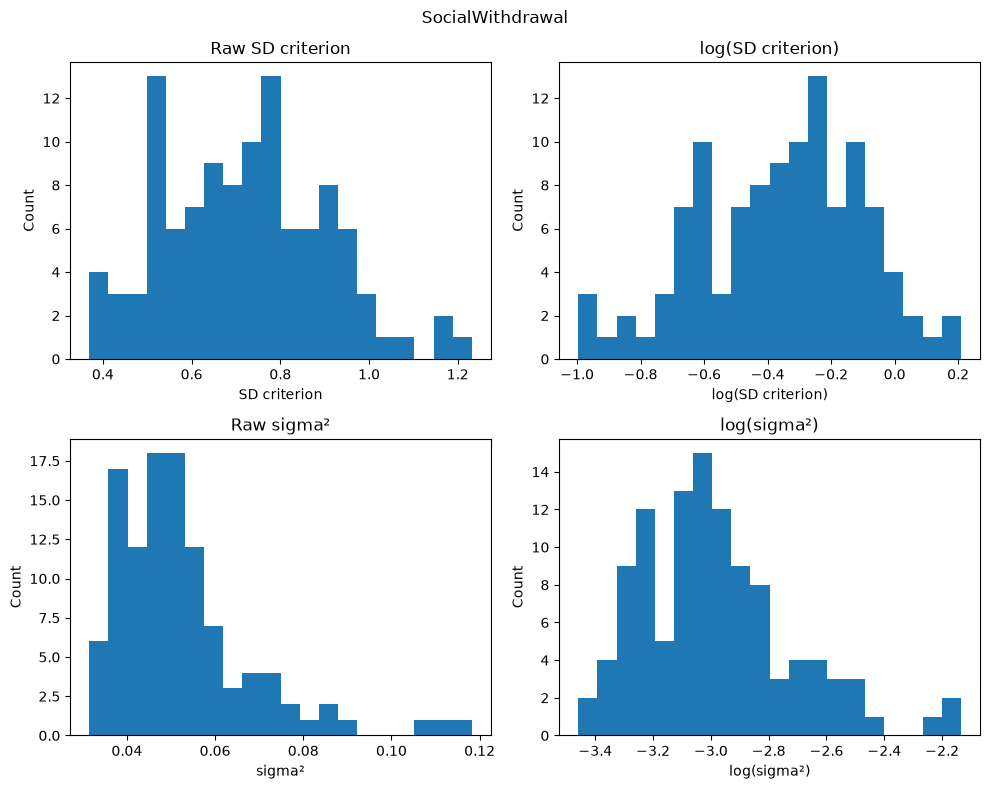

In [12]:
for scale, df in tables.items():

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # Criterion SD
    axes[0, 0].hist(df["sd_criterion"], bins=20)
    axes[0, 0].set_title("Raw SD criterion")
    axes[0, 0].set_xlabel("SD criterion")
    axes[0, 0].set_ylabel("Count")

    axes[0, 1].hist(df["log_sd_criterion"], bins=20)
    axes[0, 1].set_title("log(SD criterion)")
    axes[0, 1].set_xlabel("log(SD criterion)")
    axes[0, 1].set_ylabel("Count")

    # Sigma squared
    axes[1, 0].hist(df["sigmasq_mean"], bins=20)
    axes[1, 0].set_title("Raw sigma²")
    axes[1, 0].set_xlabel("sigma²")
    axes[1, 0].set_ylabel("Count")

    axes[1, 1].hist(df["log_sigmasq"], bins=20)
    axes[1, 1].set_title("log(sigma²)")
    axes[1, 1].set_xlabel("log(sigma²)")
    axes[1, 1].set_ylabel("Count")

    fig.suptitle(scale)
    plt.tight_layout()
    plt.show()

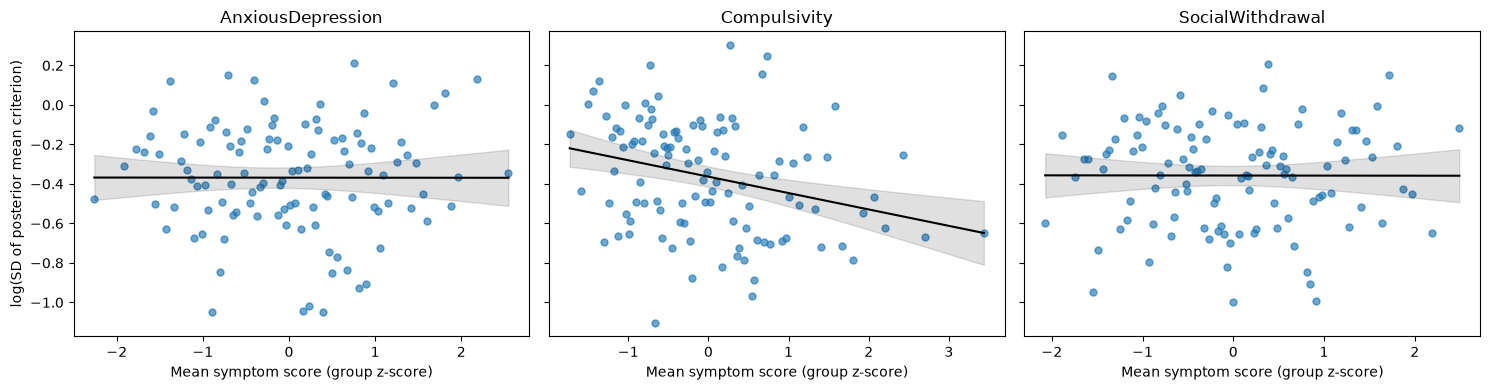

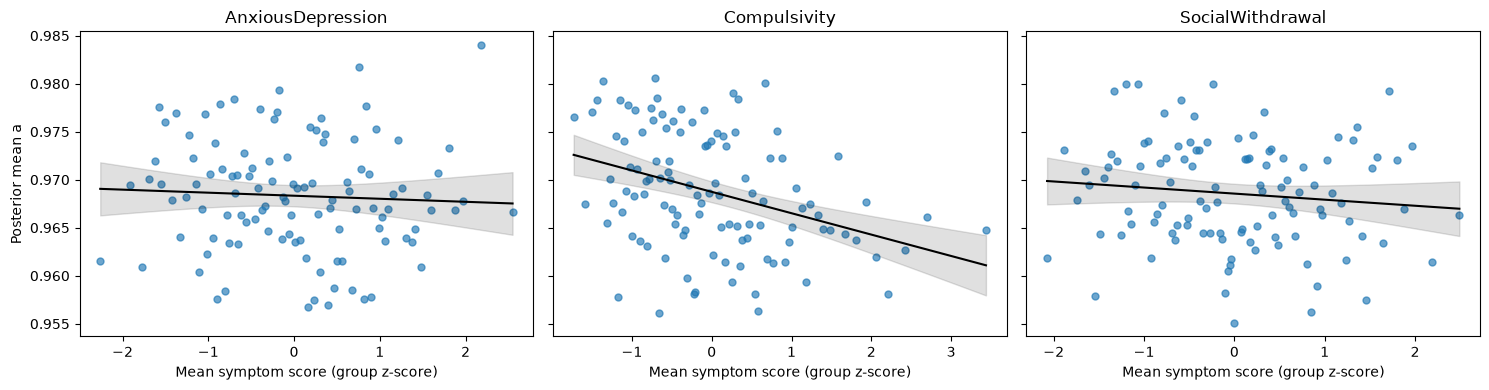

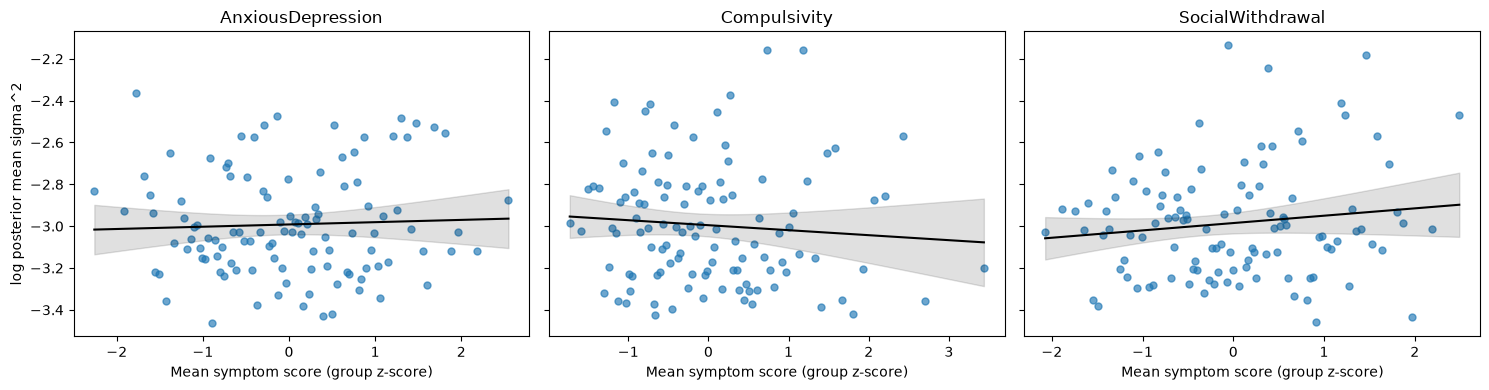

In [13]:

plot_ylabels = {
    "log_sd_criterion": "log(SD of posterior mean criterion)",
    "a_mean": "Posterior mean a",
    "log_sigmasq": "log posterior mean sigma^2",
}

for outcome in outcomes:

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 4),
        sharey=True
    )

    for ax, scale in zip(axes, run_ids):

        df = tables[scale]
        fit = models[(scale, outcome)]

        ax.scatter(
            df["symptom_z"],
            df[outcome],
            alpha=0.65,
            s=25
        )

        grid = pd.DataFrame({
            "symptom_z": np.linspace(
                df["symptom_z"].min(),
                df["symptom_z"].max(),
                100
            )
        })

        prediction = fit.get_prediction(
            sm.add_constant(grid, has_constant="add")
        ).summary_frame()

        ax.plot(
            grid["symptom_z"],
            prediction["mean"],
            color="black"
        )

        ax.fill_between(
            grid["symptom_z"],
            prediction["mean_ci_lower"],
            prediction["mean_ci_upper"],
            color="black",
            alpha=0.12
        )

        ax.set(
            title=scale,
            xlabel="Mean symptom score (group z-score)"
        )

    axes[0].set_ylabel(plot_ylabels[outcome])

    fig.tight_layout()

    fig.savefig(
        output_dir / f"symptoms_vs_{outcome}.pdf",
        bbox_inches="tight"
    )

    plt.show()

A positive beta indicates more criterion variability at higher symptom scores; a negative beta indicates less. Interpret effect sizes and uncertainty together with Holm-adjusted p-values. A smaller p-value than in the individual-level analysis alone does not demonstrate a stronger relationship: pooling changes the unit of analysis and the outcome. These three fits reuse the same participants and are not independent replications. No arbitrary outlier exclusion is applied.

## Five symptom-score groups: MAD and SD

For visualization only, split superparticipants into five approximately equally sized groups using their mean symptom score. Identical scores stay together; tied quantile boundaries can produce fewer than five groups. Each point is the unweighted mean across superparticipants in that bin. Error bars show **±1 standard error between superparticipants**, not posterior credible intervals. MAD means mean absolute deviation from the trajectory mean (not median absolute deviation). Both measures exclude padded trials and use the posterior mean trajectory. Regressions above still use continuous scores.


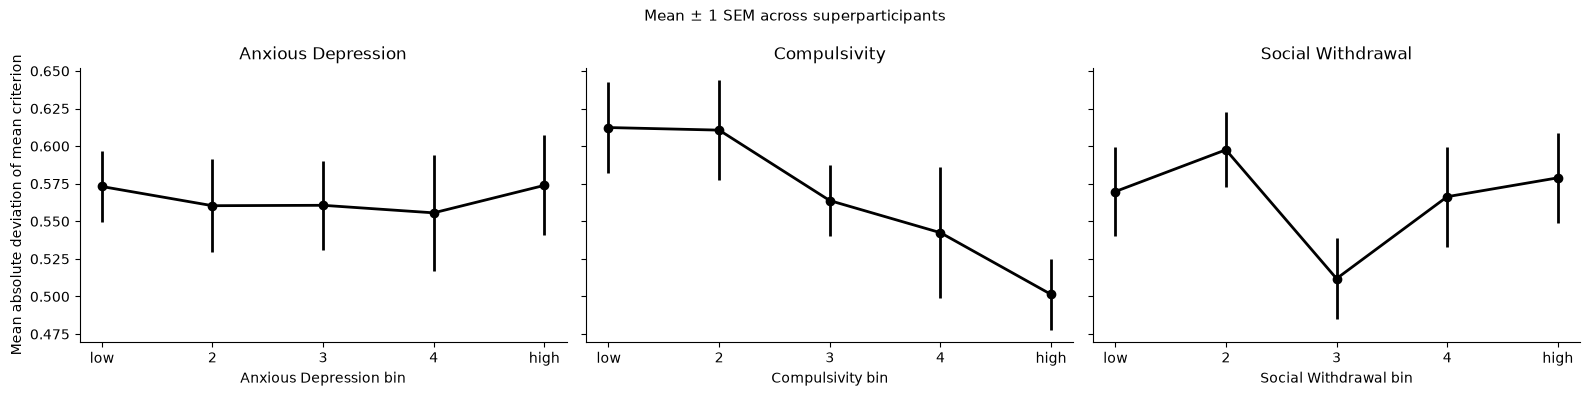

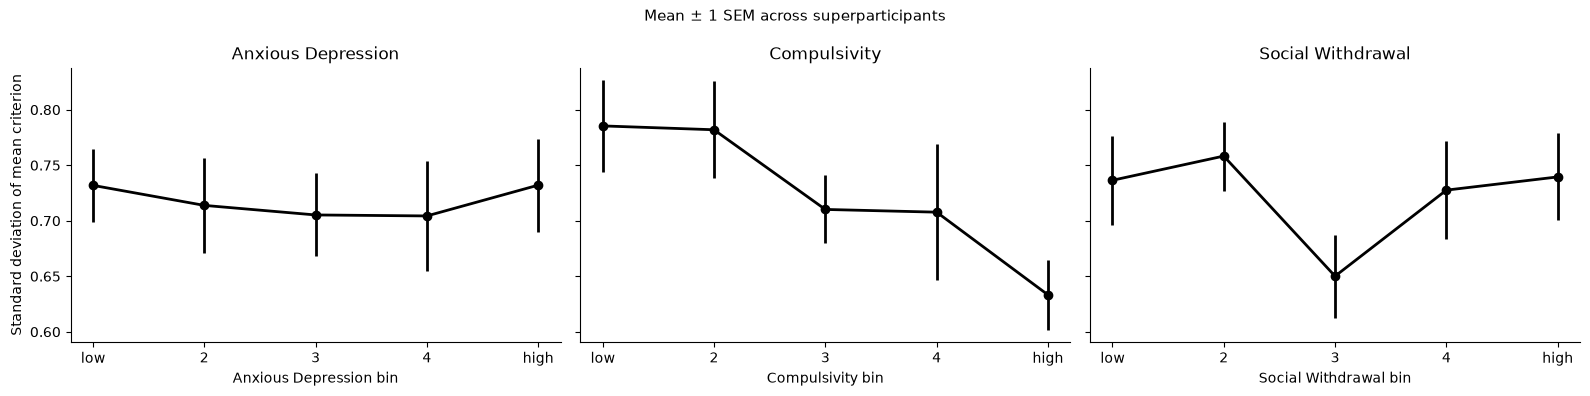

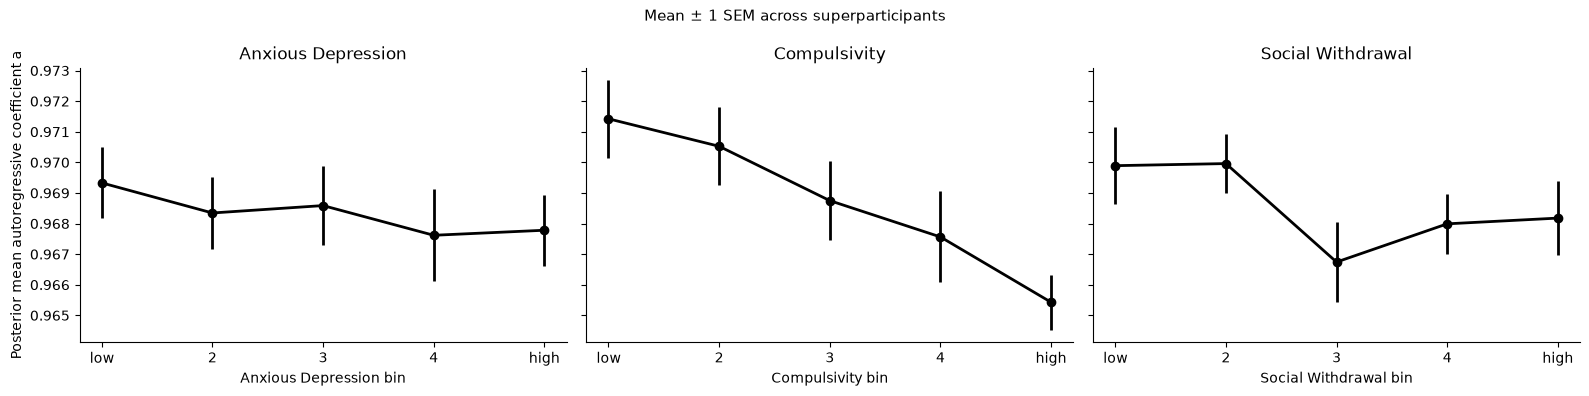

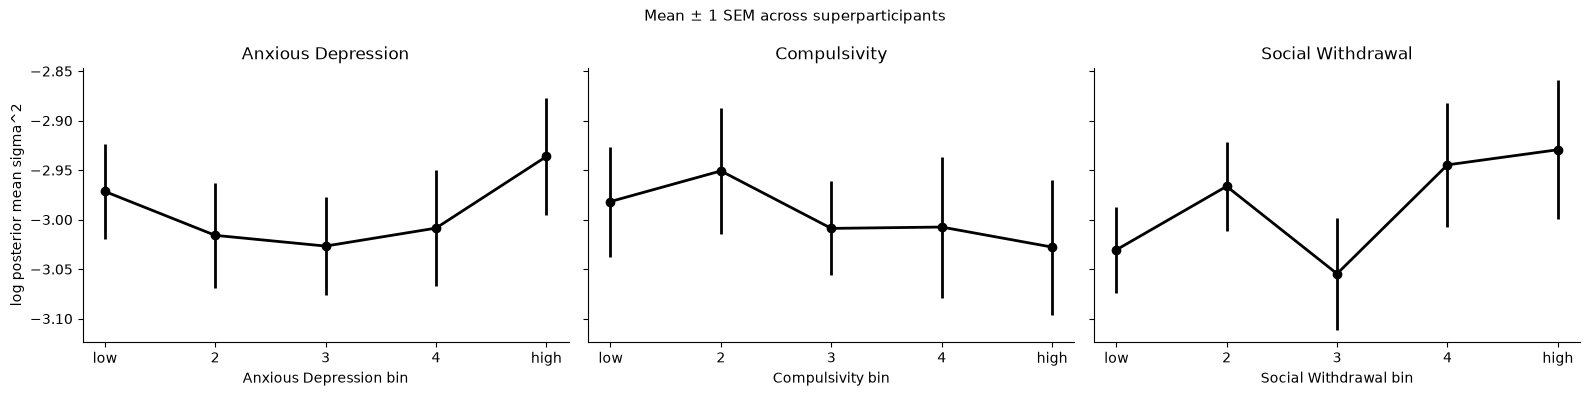

In [14]:
# Create the bins once so both figures use the same groups.
plot_titles = {"AnxiousDepression": "Anxious Depression",
               "Compulsivity": "Compulsivity",
               "SocialWithdrawal": "Social Withdrawal"}
binned_summaries = []
for scale, df in tables.items():
    plot_data = df.copy()
    plot_data["score_bin"] = pd.qcut(plot_data["symptom_mean"], q=5,
                                    labels=False, duplicates="drop") + 1
    if plot_data["score_bin"].isna().any():
        raise ValueError(f"Cannot form score groups for {scale}.")
    if plot_data["score_bin"].nunique() != 5:
        print(f"{scale}: ties produced {plot_data['score_bin'].nunique()} bins.")
    for metric in ("mad_criterion","sd_criterion","a_mean","log_sigmasq"):
        summary = (plot_data.groupby("score_bin")[metric]
                   .agg(mean="mean", sem="sem", n="count").reset_index())
        summary["scale"] = scale
        summary["metric"] = metric
        binned_summaries.append(summary)

binned_results = pd.concat(binned_summaries, ignore_index=True)
binned_results.to_csv(output_dir / "binned_criterion_summary.csv", index=False)

for metric, ylabel in (

    ("mad_criterion",
     "Mean absolute deviation of mean criterion"),

    ("sd_criterion",
     "Standard deviation of mean criterion"),

    ("a_mean",
     "Posterior mean autoregressive coefficient a"),

    ("log_sigmasq",
     "log posterior mean sigma^2"),

):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, scale in zip(axes, run_ids):
        summary = binned_results.loc[
            (binned_results["scale"] == scale) &
            (binned_results["metric"] == metric)
        ].sort_values("score_bin")
        x = summary["score_bin"].to_numpy()
        ax.errorbar(x, summary["mean"], yerr=summary["sem"],
                    fmt="o-", color="black", linewidth=2, capsize=0)
        labels = [str(int(i)) for i in x]
        labels[0], labels[-1] = "low", "high"
        ax.set_xticks(x, labels)
        ax.set_title(plot_titles[scale])
        ax.set_xlabel(f"{plot_titles[scale]} bin")
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel(ylabel)
    fig.suptitle("Mean ± 1 SEM across superparticipants", fontsize=11)
    fig.tight_layout()
    fig.savefig(output_dir / f"binned_{metric}.pdf", bbox_inches="tight")
    fig.savefig(output_dir / f"binned_{metric}.png", dpi=200, bbox_inches="tight")
    plt.show()
